# Conducting EDA on the 311 API dataset

## Import Depedencies

In [12]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests
import sys
# Add your source directory to the Python path
sys.path.append('../src')

## Get the data using the batch API

In [13]:
from fetch_nyc_311 import fetch_nyc_311

raw_path = "../data/nyc_311_complaints.csv"
snapshot_path = "../data/nyc_311_snapshot.csv"

# Always fetch fresh data (may still fail, but we want diagnostics)
print("Fetching fresh data from API...")
df_raw = fetch_nyc_311(save_path=raw_path)

# Try to load snapshot safely
df = None
if os.path.exists(snapshot_path) and os.path.getsize(snapshot_path) > 0:
    try:
        df = pd.read_csv(snapshot_path)
        print("Using existing insight snapshot.")
    except pd.errors.EmptyDataError:
        print("Snapshot file exists but is empty or corrupted. Falling back to fresh data.")
        df = None

# If snapshot couldn't be loaded or doesn't exist, create one
if df is None:
    if df_raw.empty:
        raise ValueError("Fetched data is empty — cannot proceed.")
    df_raw.to_csv(snapshot_path, index=False)
    print("Saved new snapshot for insight generation.")
    df = df_raw.copy()

print("Data ready for analysis.")
df.head()

Fetching fresh data from API...

Requesting rows 0 to 1000...
Status code: 200
Content-Length: None
Rate limit remaining: None
Request attempt: 1
Records returned: 1000

Requesting rows 1000 to 2000...
Status code: 200
Content-Length: None
Rate limit remaining: None
Request attempt: 1
Records returned: 1000

Requesting rows 2000 to 3000...
Status code: 200
Content-Length: None
Rate limit remaining: None
Request attempt: 1
Records returned: 1000

Requesting rows 3000 to 4000...
Status code: 200
Content-Length: None
Rate limit remaining: None
Request attempt: 1
Records returned: 1000

Requesting rows 4000 to 5000...
Status code: 200
Content-Length: None
Rate limit remaining: None
Request attempt: 1
Records returned: 1000

Requesting rows 5000 to 6000...
Status code: 200
Content-Length: None
Rate limit remaining: None
Request attempt: 1
Records returned: 1000

Requesting rows 6000 to 7000...
Status code: 200
Content-Length: None
Rate limit remaining: None
Request attempt: 1
Records return

,unique_key,created_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,incident_address,street_name,...,intersection_street_2,landmark,vehicle_type,taxi_pick_up_location,closed_date,bridge_highway_name,road_ramp,bridge_highway_segment,taxi_company_borough,bridge_highway_direction
0,64954277,2025-05-16T02:29:05.000,DSNY,Department of Sanitation,Graffiti,Graffiti,Comercial,11101,24-10 40 AVENUE,40 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,64962294,2025-05-16T00:51:31.000,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10029,332 EAST 115 STREET,EAST 115 STREET,...,1 AVENUE,EAST 115 STREET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,64960671,2025-05-16T00:51:00.000,DOT,Department of Transportation,Traffic Signal Condition,Controller,NaN,NaN,NaN,NaN,...,BRUCKNER EXPY W S/R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,64960563,2025-05-16T00:50:46.000,DOHMH,Department of Health and Mental Hygiene,Rodent,Rat Sighting,3+ Family Apt. Building,10452,963 WOODYCREST AVENUE,WOODYCREST AVENUE,...,WEST 163 STREET,WOODYCREST AVENUE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,64960603,2025-05-16T00:50:33.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11204,1650 56 STREET,56 STREET,...,17 AVENUE,56 STREET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Quick check on DataFrame

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   unique_key                      10000 non-null  object
 1   created_date                    10000 non-null  object
 2   agency                          10000 non-null  object
 3   agency_name                     10000 non-null  object
 4   complaint_type                  10000 non-null  object
 5   descriptor                      10000 non-null  object
 6   location_type                   8863 non-null   object
 7   incident_zip                    9919 non-null   object
 8   incident_address                9682 non-null   object
 9   street_name                     9682 non-null   object
 10  address_type                    9960 non-null   object
 11  city                            9383 non-null   object
 12  facility_type                   672 non-null   

In [15]:
# Assuming previous cell  with sys.path.append() was ran
# My File in ../src/
from clean_data import clean_311_data 
df = clean_311_data(df)
df.head(1)

Starting NYC 311 data cleaning...
Original shape: (10000, 41)

Columns with >80% missing values (to inspect):
taxi_company_borough        0.9986
bridge_highway_direction    0.9974
road_ramp                   0.9967
due_date                    0.9965
bridge_highway_name         0.9944
bridge_highway_segment      0.9944
taxi_pick_up_location       0.9880
vehicle_type                0.9394
facility_type               0.9328
dtype: float64 

Dropped 9 columns with >90% missing data.
New shape after column drop: (10000, 32)

Filled missing values in categorical columns: ['borough', 'complaint_type', 'descriptor', 'location_type']
Standardized 'created_date' and 'closed_date' columns.
Added 'response_time', 'day_of_week', and 'hour' columns.
Cleaned 'incident_zip' column.
Converted categorical columns to 'category' dtype.
Dropped 206 rows missing latitude or longitude.
Cleaned text fields: ['incident_address', 'descriptor']
Flattened dict-type columns: ['location']
Example of expanded nested

,unique_key,created_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,incident_address,street_name,...,intersection_street_1,intersection_street_2,landmark,closed_date,response_time,day_of_week,hour,location_latitude,location_longitude,location_human_address
0,64954277,2025-05-16 02:29:05,DSNY,Department of Sanitation,Graffiti,Graffiti,Comercial,11101,24-10 40 AVENUE,40 AVENUE,...,NaN,NaN,NaN,NaT,NaN,Friday,2,40.75380190146572,-73.93854694925581,"{""address"": """", ""city"": """", ""state"": """", ""zip""..."


## Now conduct some EDA

Data shape: (9794, 37)

Column types:
 object            28
float64            3
datetime64[ns]     2
category           1
category           1
category           1
int32              1
Name: count, dtype: int64

Missing values (non-zero only):
 street_name                        281
address_type                        14
city                               493
resolution_description            3113
resolution_action_updated_date    2661
bbl                               1060
cross_street_1                    2215
cross_street_2                    2206
intersection_street_1             2503
intersection_street_2             2493
landmark                          3201
closed_date                       5095
response_time                     5095
dtype: int64

Top 10 Complaint Types:
 complaint_type
Illegal Parking            1754
Noise - Residential         789
Noise - Street/Sidewalk     564
Blocked Driveway            454
UNSANITARY CONDITION        364
Abandoned Vehicle           279
N

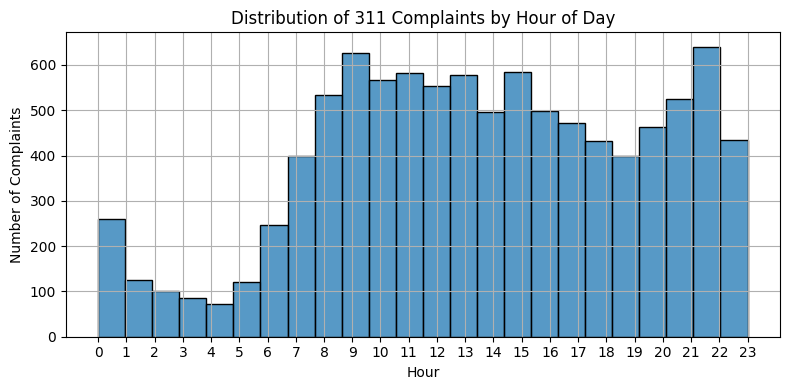

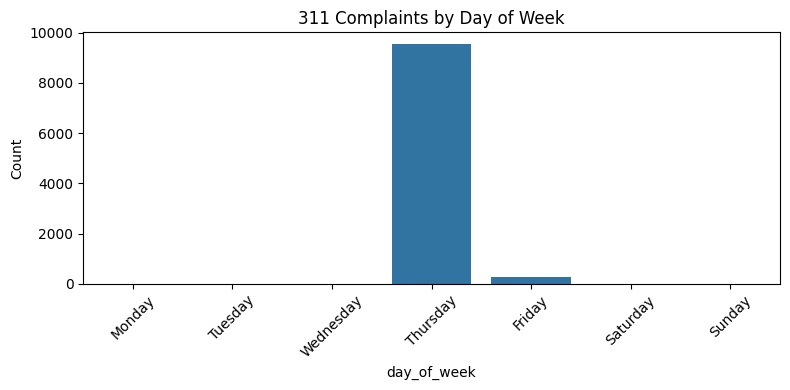

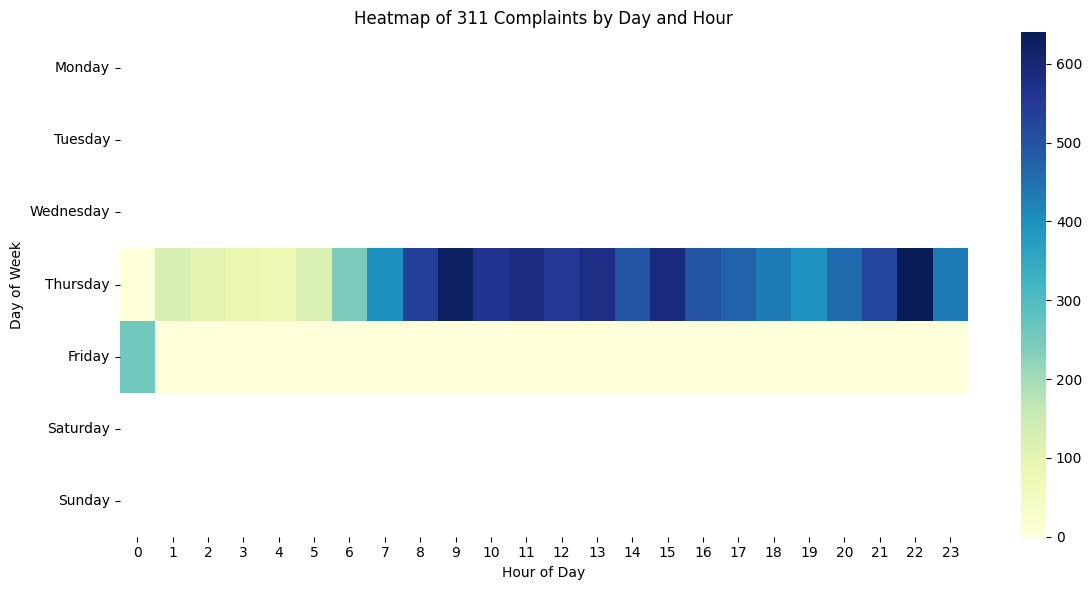

In [16]:

# Load cleaned data
# df = clean_311_data(df_raw)   # if not already done

# Display shape and column types
print("Data shape:", df.shape)
print("\nColumn types:\n", df.dtypes.value_counts())

# Count missing values (should be few after cleaning)
missing_summary = df.isnull().sum()
print("\nMissing values (non-zero only):\n", missing_summary[missing_summary > 0])

# Top complaint types
top_complaints = df['complaint_type'].value_counts().head(10)
print("\nTop 10 Complaint Types:\n", top_complaints)

# Complaints by Borough
complaints_by_borough = df['borough'].value_counts()
print("\nComplaints by Borough:\n", complaints_by_borough)

# Average response time by complaint type
if 'response_time' in df.columns:
    avg_response = df.groupby('complaint_type')['response_time'].mean().sort_values(ascending=False).head(10)
    print("\nTop 10 Complaint Types by Avg. Response Time:\n", avg_response)

# Time of day complaints histogram
plt.figure(figsize=(8, 4))
sns.histplot(df['hour'], bins=24, kde=False)
plt.title("Distribution of 311 Complaints by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Complaints")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

# Day of week complaint frequency
plt.figure(figsize=(8, 4))
sns.countplot(x='day_of_week', data=df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title("311 Complaints by Day of Week")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Heatmap of complaints by hour + day
heatmap_data = pd.crosstab(df['day_of_week'], df['hour'])
heatmap_data = heatmap_data.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title("Heatmap of 311 Complaints by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

## Insight: 
    ~ Most calls came in on Thursday. We should consider dropping days that have fewer than 500 rows (less than 10% of the data).

    ~ Day = Friday = Outlier

    ~Complaints occur mostly during daytime hours, which is expected. No filtering by hour is necessary.

In [17]:
# Get complaint counts by day
day_counts = df['day_of_week'].value_counts()

# Days with at least 150 complaints
valid_days = day_counts[day_counts >= 500].index.tolist()

# Filter the DataFrame
df = df[df['day_of_week'].isin(valid_days)]

print(f"Filtered dataset to include only days with ≥500 complaints.")
print(f"Remaining days: {valid_days}")
print(f"New shape: {df.shape}")


Filtered dataset to include only days with ≥500 complaints.
Remaining days: ['Thursday']
New shape: (9534, 37)


## Save final cleaned DataFrame to CSV for use later. Pipeline Complete.

In [19]:
cleaned_df = df
cleaned_df.to_csv('../data/nyc_311_complaints_cleaned.csv')

In [10]:
## Could add a push to SQL here, which could be connected to Tableau or Streamlit